# Proyecto #2: Clases y Objetos — Visualización

### Integrantes: Sebastián Calvo Solano, Isaac Rodríguez Zuñiga
### Colegio Universitario de Cartago
### Programación 2

## Visualizador

Este notebook consume la clase `Visualizador`, que a su vez se apoya en
`ProcesadorEDA` y `GestorPartidos`. Cada gráfico busca contar una historia
concreta sobre casi un siglo de Copas Mundiales, no solo mostrar un número.

#### Llamado de Clases y Librerías

In [1]:
import sys
from pathlib import Path

raiz_proyecto = Path.cwd().parent
sys.path.append(str(raiz_proyecto))

from src.ingesta.CargadorDatos import CargadorDatos
from src.gestor.GestorPartidos import GestorPartidos
from src.visualizacion.Visualizador import Visualizador
from src.eda.EDA import ProcesadorEDA

Construimos el pipeline completo una sola vez: ingesta → gestor → visualizador.

In [2]:
cargador = CargadorDatos(
    url_source="https://raw.githubusercontent.com/martj42/international_results/master/results.csv",
    raw_path="../data/raw",
    processed_path="../data/processed",
)
df_final = cargador.ejecutar()

gestor = GestorPartidos(df_final)
visualizador = Visualizador(gestor)

print(f"Filas: {visualizador.filas} | Columnas: {visualizador.columnas}")

INFO:src.ingesta.CargadorDatos:Usando cache local: ..\data\raw\raw_results.csv
INFO:src.ingesta.CargadorDatos:Filtro aplicado para 'FIFA World Cup': 1068 filas


OSError: [Errno 22] Invalid argument: '..\\data\\raw\\raw_results.csv'

## ¿Quién domina y quién pierde? La diferencia de gol como termómetro histórico

Este gráfico de tornado enfrenta a las 5 selecciones más dominantes contra las 5 que más han
sufrido, mostrando de un vistazo casi un siglo de asimetría futbolística.

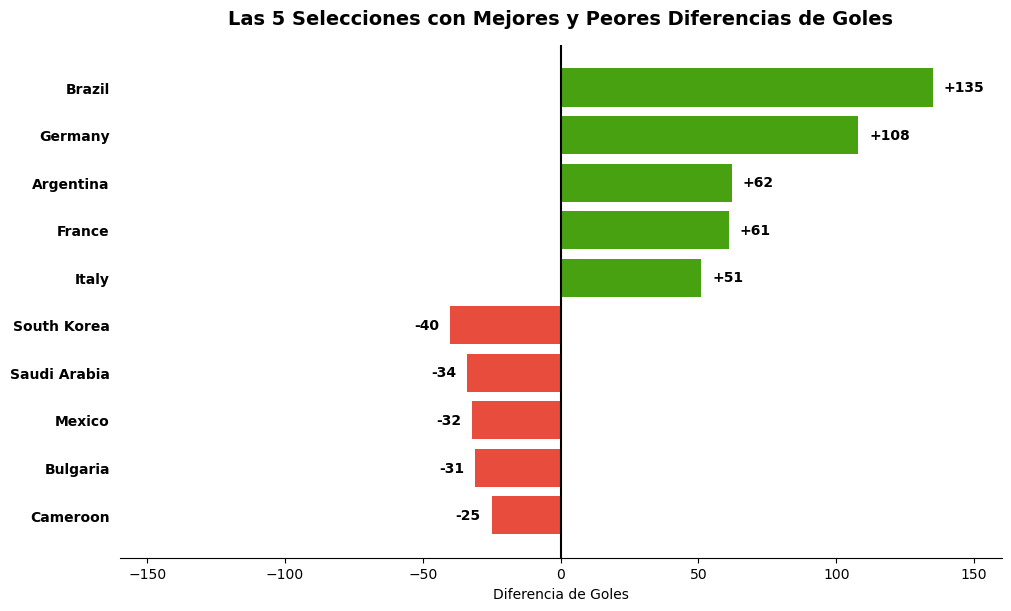

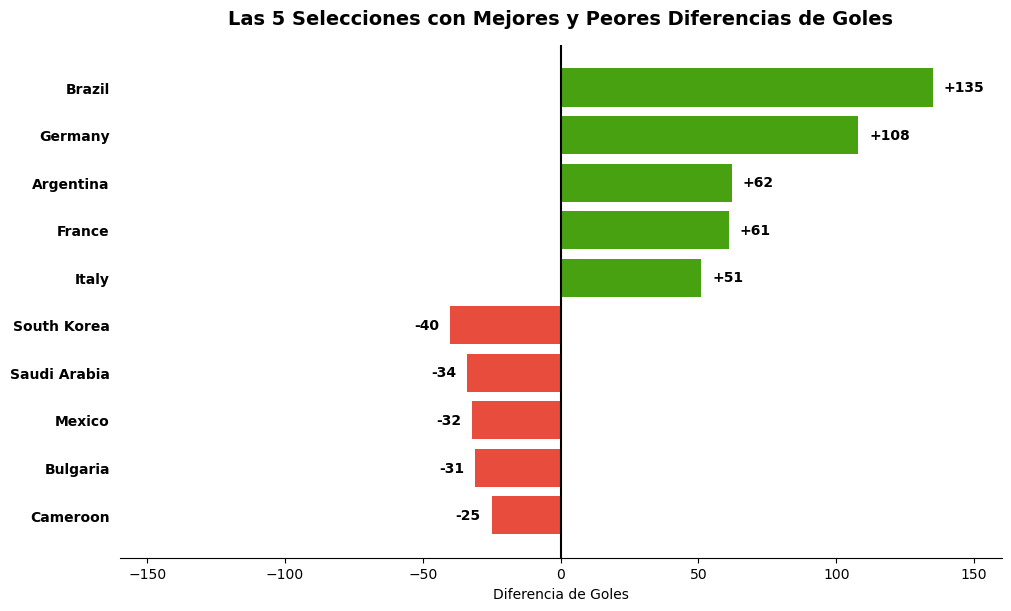

In [ ]:
visualizador.grafico_diferencia_goles()

Brasil y Alemania destacan con una diferencia ampliamente positiva, reflejo
de décadas de dominio ofensivo y defensivo combinado. En el extremo opuesto,
las selecciones con diferencia negativa muestran participaciones marcadas
por goleadas recibidas más que anotadas — el gráfico hace evidente la brecha
de forma inmediata, sin necesidad de leer una tabla completa.

## El gol a través del tiempo: ¿el fútbol mundialista es cada vez más ofensivo?

Esta línea de tiempo recorre cada edición del Mundial y suma los goles
anotados en total. Permite ver si el torneo se ha vuelto más o menos
prolífico en gol conforme crece el número de selecciones participantes.
- De Catar 2022: 32 selecciones
- A USA-MEX-CAN 2026: 48 selecciones

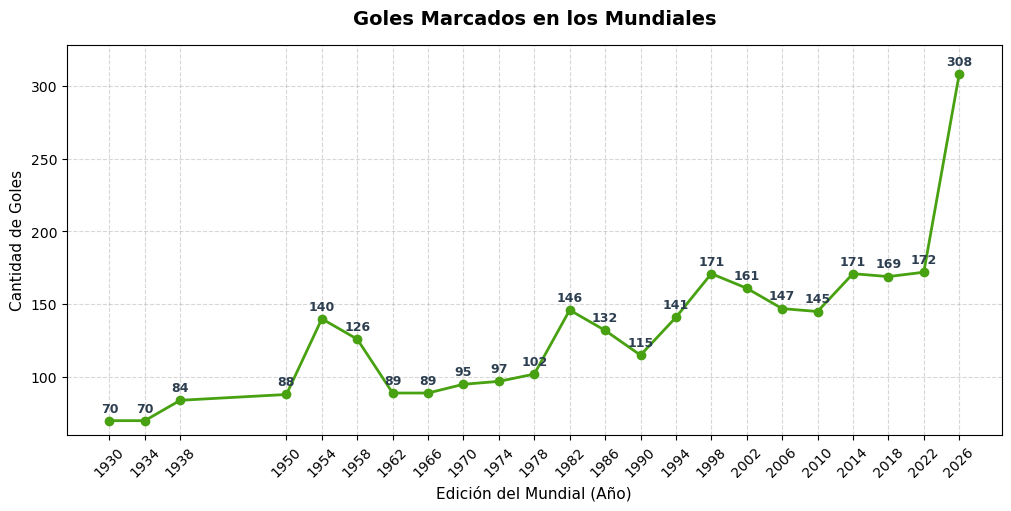

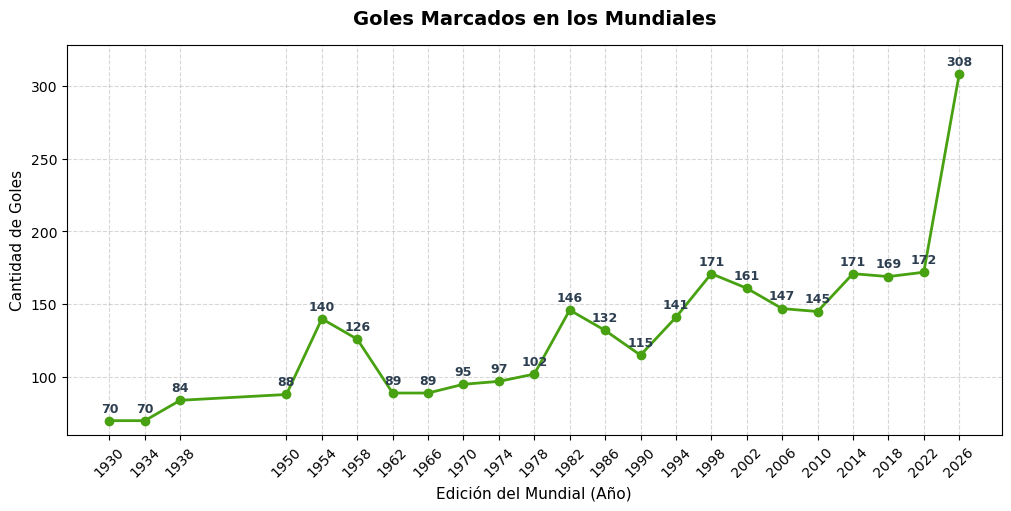

In [ ]:
visualizador.goles_por_mundial()

Se observa una tendencia general al alza, coherente con la expansión del
torneo (más selecciones, más partidos totales). Las ediciones más recientes
concentran las cifras más altas de goles, mientras que los primeros
mundiales, con formatos más reducidos, muestran totales bastante menores.

## El ADN de un campeón: comparando a las 5 mejores selecciones históricas

Un gráfico de telaraña permite comparar simultáneamente siete dimensiones
de desempeño (victorias, empates, derrotas, goles a favor y en contra,
diferencia de gol y puntos) para las 5 selecciones con mejor historial
combinado según el sistema de puntos actual.

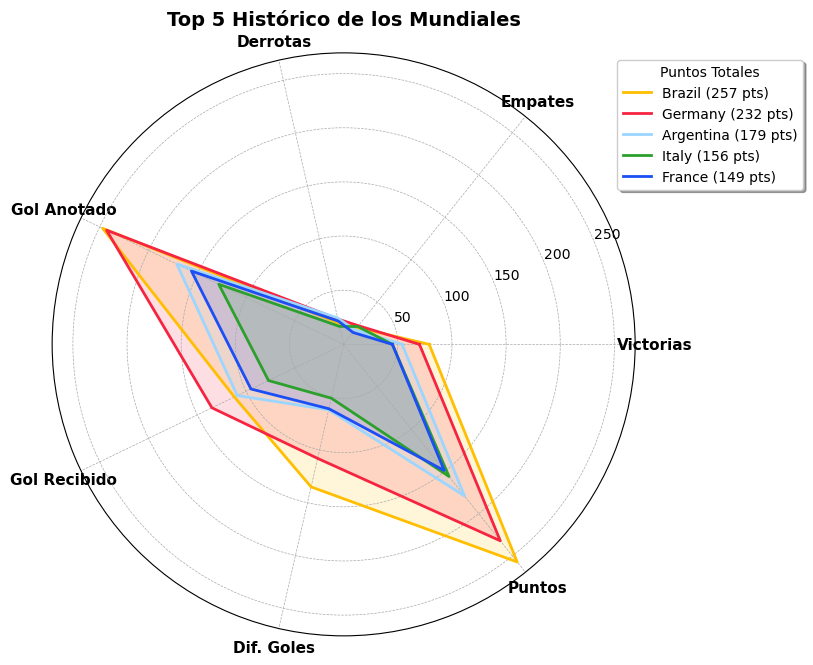

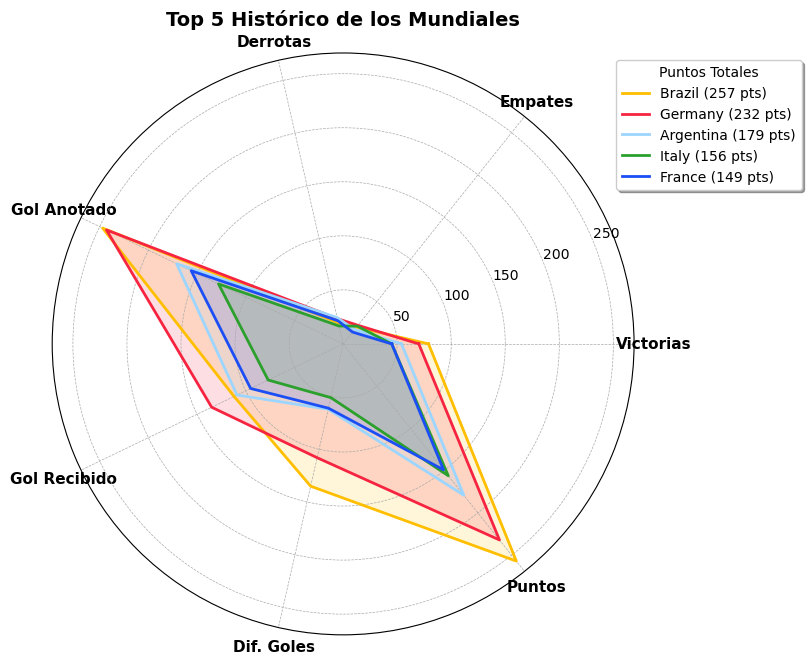

In [ ]:
visualizador.mejores_cinco_selecciones()

La forma de cada polígono cuenta su propia historia: una selección con un
polígono grande y regular refleja dominio constante en todas las facetas del
juego, mientras que asimetrías en la figura (por ejemplo, muchas victorias
pero también más derrotas relativas) delatan un estilo más irregular.

## ¿Jugar en casa realmente ayuda a ganar el título?

Comparamos cuántas veces el país anfitrión terminó siendo campeón de su
propio Mundial, frente a cuántas veces el título se lo llevó otra selección.
Esto conecta directamente con la ventaja local que ya analizamos a nivel de
partido individual en `GestorPartidos.ventaja_local()`.

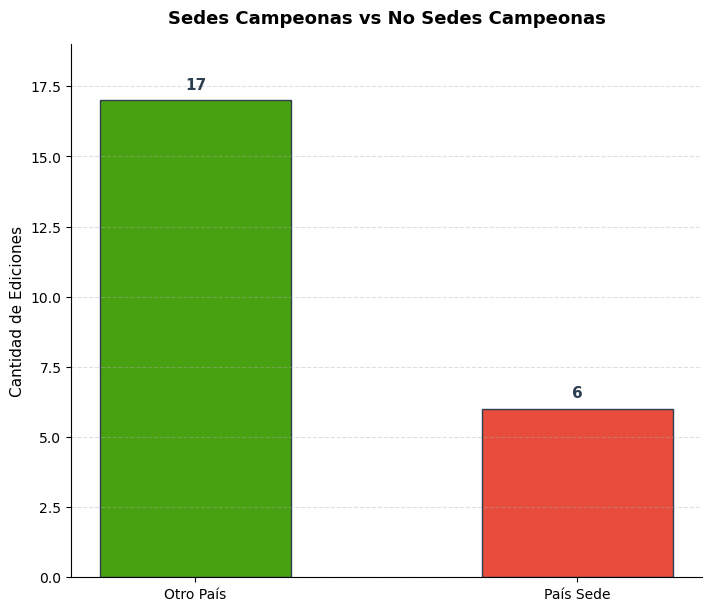

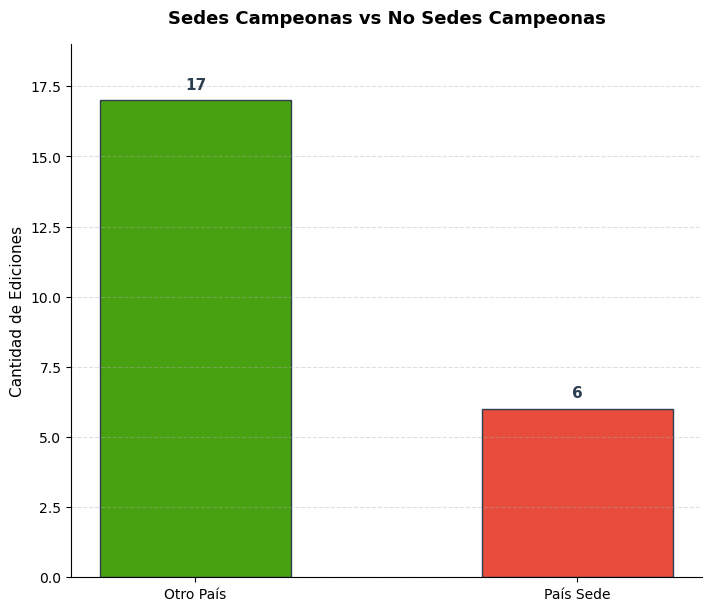

In [ ]:
visualizador.campeon_sede_otro()

La mayoría de campeonatos han sido ganados por selecciones distintas al
país anfitrión, lo que sugiere que, aunque jugar en casa ofrece ventajas
puntuales por partido, no es un factor determinante para ganar el torneo
completo — ganar un Mundial exige sostener el nivel durante varias rondas
consecutivas, no solo un partido con apoyo local.

## La gloria de quedar segundo: las selecciones que más veces han llegado a la final sin coronarse

Llegar a una final de Mundial ya es una hazaña histórica. Este gráfico
resalta a las selecciones que, pese a llegar múltiples veces a esa instancia,
no lograron levantar el título en esas ocasiones.

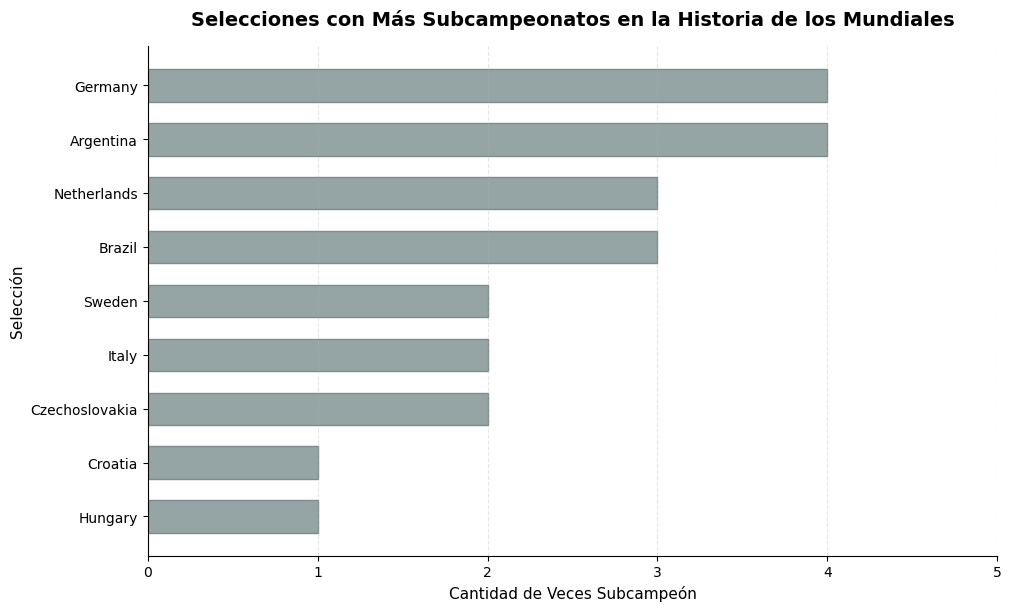

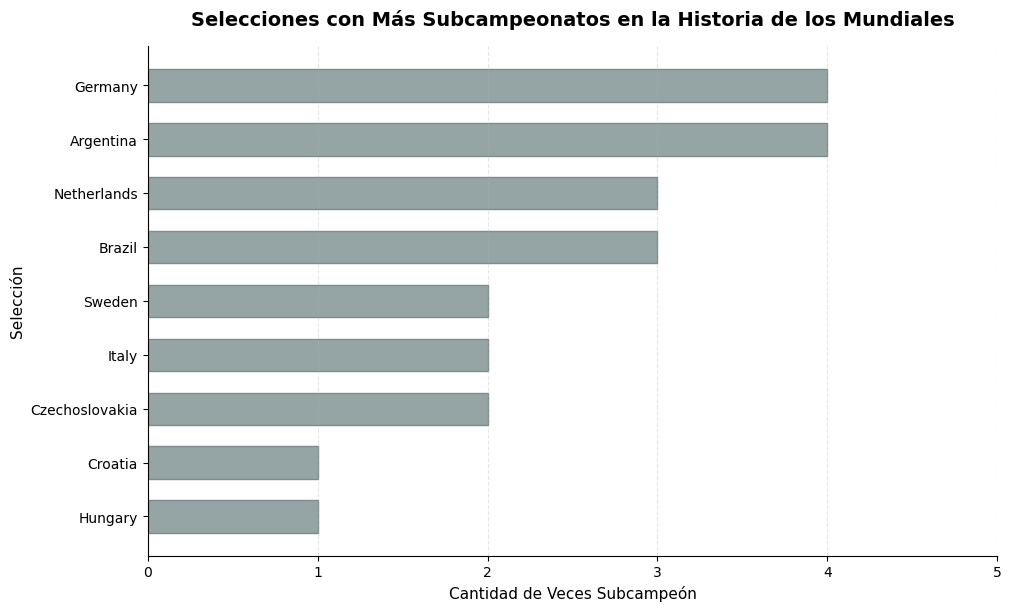

In [ ]:
visualizador.subcampeones()

Algunas selecciones acumulan varios subcampeonatos, lo que refleja
programas futbolísticos consistentemente competitivos a nivel de élite,
aunque sin la ventaja decisiva que separa a un campeón de un finalista.